Project Title: AI Governance and LLM Engineering Learning Assistant

Project Objective: The goal of this project is to fine-tune an instruction-following language model to provide educational and domain-specific responses related to AI Governance and LLM Engineering concepts.

The model is intended for learning and demonstration purposes as part of an LLM Fine-Tuning portfolio project.

# General dataset instruction-following

Source: Databricks Dolly 15K dataset.

Number of selected examples: 100

Selection criteria: Only useful instruction-following examples were selected using keyword-based filtering.

Examples include:

What is...
Explain...
Compare...
Describe...
Summarize...
Based on...
Purpose: The general dataset is included to preserve the model's instruction-following capabilities while fine-tuning it on a specialized domain.

In [ ]:
!pip install -q -U transformers datasets peft accelerate trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.4 MB/s eta 0:00:00


In [ ]:
from datasets import load_dataset

raw_dataset = load_dataset(
    "databricks/databricks-dolly-15k",
    split="train"
)

print(raw_dataset)
print(raw_dataset.column_names)
print(raw_dataset[0])

README.md:   0%|          | 0.00/8.20k [00:00<?, ?B/s]

databricks-dolly-15k.jsonl: reconstructing file:   0%|          |  0.00B / 13.1MB            

databricks-dolly-15k.jsonl: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'context', 'response', 'category'],
    num_rows: 15011
})
['instruction', 'context', 'response', 'category']
{'instruction': 'When did Virgin Australia start operating?', 'context': "Virgin Australia, the trading name of Virgin Australia Airlines Pty Ltd, is an Australian-based airline. It is the largest airline by fleet size to use the Virgin brand. It commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route. It suddenly found itself as a major airline in Australia's domestic market after the collapse of Ansett Australia in September 2001. The airline has since grown to directly serve 32 cities in Australia, from hubs in Brisbane, Melbourne and Sydney.", 'response': 'Virgin Australia commenced services on 31 August 2000 as Virgin Blue, with two aircraft on a single route.', 'category': 'closed_qa'}


In [ ]:
#بما ان المعلومات تقريبا عامه،وممكن تأثر على الاداء، را اسوي فلتره بكلمات معينه


useful_keywords = [
    "what is",
    "explain",
    "why",
    "difference",
    "compare",
    "summarize",
    "based on",
    "according to",
    "list",
    "describe"
]

def is_useful_instruction(example):
    instruction = example["instruction"].lower().strip()

    return any(
        keyword in instruction
        for keyword in useful_keywords
    )

useful_dolly = raw_dataset.filter(is_useful_instruction)

general_dataset = (useful_dolly.shuffle(seed=42).select(range(min(100, len(useful_dolly)))))

def standardize_dolly_example(example):
    return {
        "instruction": example["instruction"].strip(),
        "input": (example["context"] or "").strip(),
        "output": example["response"].strip(),
        "source": "databricks-dolly-15k",
        "domain": "general-instruction",
        "task_type": example["category"]
    }

general_dataset = general_dataset.map(standardize_dolly_example, remove_columns=general_dataset.column_names)

print(general_dataset)

Filter:   0%|          | 0/15011 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'input', 'output', 'source', 'domain', 'task_type'],
    num_rows: 100
})


In [ ]:
#previwe
for index in range(4):
    example = general_dataset[index]

    print("=" * 80)
    print("INDEX:", index)
    print("Instruction:", example["instruction"])
    print("Input:", example["input"][:300])
    print("Output:", example["output"][:300])

INDEX: 0
Instruction: What is the weather like in San Francisco, CA?
Input: 
Output: The weather in San Francisco is more mild than in the northern climates of the United States, and its seasonal weather pattern is different as well. Throughout the northern climates, there are four distinct seasons, including a warm (often hot and humid) summer and cold winter (with frequent tempera
INDEX: 1
Instruction: Please summarize Sinclair's argument in this paragraph for why longer lifespans will not lead to overpopulation.
Input: A review for Boston Magazine called Sinclair “one of science’s most controversial figures” and said many in the scientific community were skeptical of claims he made about human longevity. University of Alabama biology professor Steven N. Austad said, “David is a good friend, but I do think he’s bee
Output: Based on this paragraph, Sinclair is not concerned with the risk of overpopulation even if lifespans become longer. His rationale is the healthier people are havin

# create AI governance dataset

Source: Project-authored dataset created manually.

Number of examples: 60

Language: English

Domains covered:

AI Governance
LLM Engineering
Model Evaluation
Model Monitoring
Model Documentation
Task types:

Concept Explanation
Comparison
Decision Support
Risk Analysis
Problem Solving
Context-based Question Answering
Governance Reasoning
Purpose: The domain-specific dataset is designed to adapt the model's behavior toward educational AI Governance and LLM Engineering tasks.

In [ ]:
 #تكون بنفس صياغة الداتا فوق (نفس الاعمدة)
 from datasets import Dataset

governance_examples = [
    # ============================================================
    # 1. Core AI Governance Concepts
    # ============================================================
    {
        "instruction": "Explain AI governance to a beginner.",
        "input": "",
        "output": (
            "AI governance is the collection of policies, roles, processes, and controls "
            "used to guide how artificial intelligence systems are designed, developed, "
            "deployed, and monitored. Its purpose is to ensure that AI is used responsibly, "
            "safely, lawfully, and in alignment with organizational values."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "What is responsible AI?",
        "input": "",
        "output": (
            "Responsible AI is an approach to developing and using artificial intelligence "
            "in ways that are fair, transparent, safe, accountable, privacy-preserving, "
            "and beneficial to people. It requires both technical controls and organizational governance."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "Explain the difference between AI governance and AI ethics.",
        "input": "",
        "output": (
            "AI ethics defines the principles and values that should guide the use of artificial intelligence, "
            "such as fairness, transparency, privacy, and respect for human rights. AI governance turns those "
            "principles into practical policies, responsibilities, controls, documentation, and monitoring processes."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "comparison"
    },

    # ============================================================
    # 2. Bias, Fairness, and Transparency
    # ============================================================
    {
        "instruction": "What is algorithmic bias?",
        "input": "",
        "output": (
            "Algorithmic bias occurs when an AI system produces systematically unfair or unequal outcomes "
            "for certain individuals or groups. It may result from biased training data, incorrect labels, "
            "poor feature selection, model design choices, or the way the system is used."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "Why can labelled training data introduce bias?",
        "input": "",
        "output": (
            "Labelled data can introduce bias when annotators apply inconsistent judgments, rely on stereotypes, "
            "misunderstand cultural or linguistic differences, or are given unclear annotation guidelines. "
            "These biases can become patterns that the model learns during training."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "causal_explanation"
    },
    {
        "instruction": "Explain AI transparency in simple terms.",
        "input": "",
        "output": (
            "AI transparency means providing clear information about how an AI system was developed, "
            "what data it uses, what it is intended to do, how its performance was evaluated, "
            "and what limitations or risks users should understand."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "concept_explanation"
    },

    # ============================================================
    # 3. Documentation
    # ============================================================
    {
        "instruction": "What is the purpose of a model card?",
        "input": "",
        "output": (
            "A model card documents important information about a machine learning model, including its intended use, "
            "training approach, evaluation results, limitations, ethical considerations, risks, "
            "and situations in which the model should not be used."
        ),
        "source": "project-authored",
        "domain": "model-documentation",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "What is a data card?",
        "input": "",
        "output": (
            "A data card is structured documentation describing a dataset. It normally includes the data source, "
            "collection process, composition, labelling approach, intended uses, known limitations, "
            "privacy considerations, and possible sources of bias."
        ),
        "source": "project-authored",
        "domain": "model-documentation",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "Compare a model card with a data card.",
        "input": "",
        "output": (
            "A model card documents the model, including its performance, intended use, limitations, and risks. "
            "A data card documents the dataset, including how it was collected, labelled, structured, "
            "and what biases or privacy risks it may contain. Both support transparency and accountability."
        ),
        "source": "project-authored",
        "domain": "model-documentation",
        "task_type": "comparison"
    },

    # ============================================================
    # 4. Fine-tuning and LoRA
    # ============================================================
    {
        "instruction": "Explain fine-tuning to a beginner.",
        "input": "",
        "output": (
            "Fine-tuning is the process of taking a pretrained model and training it further on a smaller, "
            "task-specific or domain-specific dataset. This adapts the model's existing knowledge "
            "to a particular task, writing style, domain, or expected behaviour."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "Explain LoRA to a beginner.",
        "input": "",
        "output": (
            "LoRA is a parameter-efficient fine-tuning method. Instead of updating all the weights of a large model, "
            "LoRA freezes the original model and trains small low-rank adapter matrices. "
            "This reduces memory use, training time, and storage requirements."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "What is the difference between LoRA and QLoRA?",
        "input": "",
        "output": (
            "LoRA freezes the base model and trains small adapter matrices while keeping the base model "
            "at its normal numerical precision. QLoRA also trains LoRA adapters, but loads the frozen base model "
            "in a quantized format, commonly 4-bit, which further reduces memory consumption."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "comparison"
    },
    {
        "instruction": "When should LoRA be preferred over full fine-tuning?",
        "input": "",
        "output": (
            "LoRA is usually preferred when compute resources are limited, the base model is large, "
            "multiple task-specific adapters are needed, or the goal is to reduce training and storage costs. "
            "Full fine-tuning may be considered when extensive changes to the model are necessary and sufficient resources are available."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "decision_support"
    },

    # ============================================================
    # 5. Prompting, RAG, and Fine-tuning
    # ============================================================
    {
        "instruction": "Explain the difference between prompting, RAG, and fine-tuning.",
        "input": "",
        "output": (
            "Prompting changes how instructions are written without changing the model. "
            "RAG retrieves external information and adds it to the model's context at query time. "
            "Fine-tuning updates some or all model parameters to change its behaviour or improve performance on a specific task."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "comparison"
    },
    {
        "instruction": "When should RAG be used instead of fine-tuning?",
        "input": "",
        "output": (
            "RAG is usually better when the model needs access to current, frequently updated, private, "
            "or source-specific information. Fine-tuning is more suitable when the goal is to change the model's "
            "behaviour, style, output format, or performance on a repeated task."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "decision_support"
    },

    # ============================================================
    # 6. Evaluation and Monitoring
    # ============================================================
    {
        "instruction": "Why is accuracy alone not enough to evaluate a classification model?",
        "input": "",
        "output": (
            "Accuracy may be misleading when the dataset is imbalanced. A model can achieve high accuracy "
            "by predicting the majority class while failing on important minority cases. "
            "Metrics such as precision, recall, F1-score, and the confusion matrix provide a more complete evaluation."
        ),
        "source": "project-authored",
        "domain": "model-evaluation",
        "task_type": "causal_explanation"
    },
    {
        "instruction": "What does faithfulness measure when evaluating an LLM?",
        "input": "",
        "output": (
            "Faithfulness measures whether the claims in a model's answer are supported by the provided context "
            "or source material. A low faithfulness score may indicate that the model added unsupported information or hallucinated."
        ),
        "source": "project-authored",
        "domain": "model-evaluation",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "Why should a fine-tuned model be monitored after deployment?",
        "input": "",
        "output": (
            "A fine-tuned model should be monitored because user behaviour, data distributions, regulations, "
            "and operational conditions may change over time. Monitoring helps identify performance degradation, "
            "bias, hallucination, increased latency, rising costs, and other risks."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "causal_explanation"
    },

    # ============================================================
    # 7. Scenario-based Questions
    # ============================================================
    {
        "instruction": "Identify the main governance risk in the following scenario.",
        "input": (
            "A company deploys a recruitment model trained mainly on historical applications from male candidates. "
            "The company evaluates only overall accuracy before deployment."
        ),
        "output": (
            "The main governance risk is discriminatory bias. Because the historical training data underrepresents "
            "female candidates, the model may learn patterns that unfairly favour male applicants. "
            "The company should evaluate performance across demographic groups and review the dataset for representational bias."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "Recommend a suitable response to the following model issue.",
        "input": (
            "A customer-support LLM has high training performance, but its validation loss increases after the third epoch."
        ),
        "output": (
            "The pattern suggests overfitting. The team should consider restoring the checkpoint from the best validation epoch, "
            "reducing the number of epochs, applying early stopping, reviewing the dataset size and diversity, "
            "or increasing regularization such as dropout or weight decay."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "problem_solving"
    }
]

governance_dataset = Dataset.from_list(governance_examples)

print(governance_dataset)
print(governance_dataset.column_names)
print(governance_dataset[0])

Dataset({
    features: ['instruction', 'input', 'output', 'source', 'domain', 'task_type'],
    num_rows: 20
})
['instruction', 'input', 'output', 'source', 'domain', 'task_type']
{'instruction': 'Explain AI governance to a beginner.', 'input': '', 'output': 'AI governance is the collection of policies, roles, processes, and controls used to guide how artificial intelligence systems are designed, developed, deployed, and monitored. Its purpose is to ensure that AI is used responsibly, safely, lawfully, and in alignment with organizational values.', 'source': 'project-authored', 'domain': 'ai-governance', 'task_type': 'concept_explanation'}


In [ ]:
from datasets import concatenate_datasets
from collections import Counter
additional_governance_examples = [
    {
        "instruction": "Identify the main governance risk in the following scenario.",
        "input": (
            "A bank deploys a credit-scoring model trained on historical lending decisions. "
            "The bank does not test model performance separately across age groups."
        ),
        "output": (
            "The main governance risk is potential age-related discrimination. Historical lending "
            "decisions may contain embedded bias, and evaluating only overall performance could hide "
            "unequal error rates across age groups. The bank should perform subgroup testing, document "
            "the results, and introduce human review for high-impact decisions."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "Recommend controls for the following AI system.",
        "input": (
            "An organization uses an LLM to answer employee questions about internal HR policies."
        ),
        "output": (
            "Recommended controls include restricting retrieval to approved HR documents, applying access "
            "controls, preventing exposure of personal data, requiring citations to source policies, logging "
            "model responses, monitoring hallucination and answer relevance, and escalating uncertain or "
            "sensitive cases to HR staff."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "decision_support"
    },
    {
        "instruction": "Explain why human oversight is important in high-impact AI systems.",
        "input": "",
        "output": (
            "Human oversight is important because high-impact AI systems can affect rights, opportunities, "
            "safety, or access to essential services. Human reviewers can challenge questionable outputs, "
            "consider contextual information that the model may miss, handle exceptions, and remain accountable "
            "for the final decision."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "causal_explanation"
    },
    {
        "instruction": "Compare data drift and concept drift.",
        "input": "",
        "output": (
            "Data drift occurs when the distribution of model inputs changes over time. Concept drift occurs "
            "when the relationship between the inputs and the correct output changes. Both can reduce model "
            "performance, but concept drift directly changes what the model is expected to learn or predict."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "comparison"
    },
    {
        "instruction": "What should a team do if validation performance is much lower than training performance?",
        "input": "",
        "output": (
            "The team should investigate overfitting. Suitable actions include reviewing data leakage, reducing "
            "the number of epochs, applying early stopping, increasing training-data diversity, using stronger "
            "regularization, and evaluating whether the model is too complex for the available dataset."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "problem_solving"
    },
    {
        "instruction": "Identify the privacy risk in the following scenario.",
        "input": (
            "A customer-service chatbot stores complete user conversations, including names, phone numbers, "
            "and account details, for future model improvement."
        ),
        "output": (
            "The main risk is unnecessary collection and retention of personal data. The organization should "
            "apply data minimization, remove or mask identifiers, define a retention period, restrict access, "
            "obtain an appropriate legal basis, and prevent sensitive conversations from being reused without review."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "When is accuracy an inappropriate primary metric?",
        "input": "",
        "output": (
            "Accuracy is inappropriate as the primary metric when the classes are imbalanced or when different "
            "types of errors have different consequences. In those cases, precision, recall, F1-score, subgroup "
            "metrics, and the confusion matrix provide more useful evidence."
        ),
        "source": "project-authored",
        "domain": "model-evaluation",
        "task_type": "decision_support"
    },
    {
        "instruction": "Explain why a model should have an out-of-scope use section.",
        "input": "",
        "output": (
            "An out-of-scope use section clarifies situations in which the model was not designed or evaluated "
            "to operate. It helps prevent inappropriate deployment, sets user expectations, and reduces the risk "
            "of applying the model to high-impact or unsupported decisions."
        ),
        "source": "project-authored",
        "domain": "model-documentation",
        "task_type": "causal_explanation"
    },
    {
        "instruction": "Recommend a response when a model starts producing more hallucinations after deployment.",
        "input": "",
        "output": (
            "The team should confirm the change using a stable evaluation set, review recent input patterns, "
            "inspect prompt and retrieval changes, compare the current model version with the previous version, "
            "apply temporary safeguards, and roll back if the issue creates unacceptable risk."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "problem_solving"
    },
    {
        "instruction": "Identify the main risk in the following scenario.",
        "input": (
            "A company uses an LLM to summarize legal contracts, but does not warn users that the summaries "
            "may omit important clauses."
        ),
        "output": (
            "The main risk is overreliance on incomplete or inaccurate summaries. The system should clearly state "
            "that it does not replace legal review, preserve links to the original clauses, test omission rates, "
            "and require qualified human review before decisions are made."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "Compare transparency and explainability.",
        "input": "",
        "output": (
            "Transparency concerns the information disclosed about an AI system, such as its purpose, data, "
            "development process, performance, and limitations. Explainability concerns whether people can "
            "understand why the system produced a particular output or decision."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "comparison"
    },
    {
        "instruction": "What should be evaluated before replacing a deployed model with a new version?",
        "input": "",
        "output": (
            "The new version should be compared with the current version on task performance, subgroup fairness, "
            "safety, hallucination, latency, cost, robustness, and failure cases. The team should also confirm "
            "rollback readiness and document the reasons for approving the replacement."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "decision_support"
    },
    {
        "instruction": "Answer the question using only the provided policy.",
        "input": (
            "Policy: Models used for employment decisions must undergo bias testing before deployment and every "
            "six months after deployment.\n\nQuestion: How often must the model be tested after deployment?"
        ),
        "output": (
            "The model must undergo bias testing every six months after deployment."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "context_based_qa"
    },
    {
        "instruction": "Answer the question using only the provided policy.",
        "input": (
            "Policy: Personal data must not be used for model training unless it has an approved legal basis "
            "and has passed a privacy review.\n\nQuestion: Can personal data be used automatically for training?"
        ),
        "output": (
            "No. Personal data may be used only when there is an approved legal basis and the data has passed "
            "a privacy review."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "context_based_qa"
    },
    {
        "instruction": "Recommend the most suitable approach.",
        "input": (
            "A company needs an assistant to answer questions from policies that change every month. "
            "The required writing style is already acceptable."
        ),
        "output": (
            "RAG is the most suitable primary approach because the information changes frequently and should be "
            "retrieved from current policy documents at query time. Fine-tuning is not the best method for storing "
            "frequently updated facts."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "decision_support"
    },
    {
        "instruction": "Recommend the most suitable approach.",
        "input": (
            "A company wants a model to always produce incident reports in a fixed structure and tone."
        ),
        "output": (
            "Fine-tuning may be appropriate because the goal is to change repeated output behaviour, structure, "
            "and style. Prompt templates should be tested first, and fine-tuning can be used if prompting alone "
            "does not provide consistent results."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "decision_support"
    },
    {
        "instruction": "Why must compressed context be evaluated in a RAG system?",
        "input": "",
        "output": (
            "Compressed context must be evaluated because summarization or filtering may remove qualifications, "
            "exceptions, dates, or safety-critical information. The team should check context recall and answer "
            "faithfulness before relying on the compressed content."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "causal_explanation"
    },
    {
        "instruction": "Identify the governance issue in the following scenario.",
        "input": (
            "A team reports only the average F1-score and does not publish results for individual demographic groups."
        ),
        "output": (
            "The governance issue is insufficient subgroup evaluation. A strong average score can hide poor "
            "performance for particular groups. The team should report disaggregated metrics and investigate "
            "unequal error rates."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "What should be included in a monitoring plan for a fine-tuned LLM?",
        "input": "",
        "output": (
            "A monitoring plan should define quality and safety metrics, acceptable thresholds, evaluation "
            "frequency, data-drift checks, latency and cost monitoring, user-feedback channels, incident escalation, "
            "responsible owners, retraining triggers, versioning, and rollback procedures."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "concept_explanation"
    },
    {
        "instruction": "How can a team reduce catastrophic forgetting during incremental retraining?",
        "input": "",
        "output": (
            "The team can mix representative older examples with new data, use a conservative learning rate, "
            "limit the number of training epochs, evaluate both new and previous capabilities, and keep earlier "
            "model versions available for comparison and rollback."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "problem_solving"
    }
]

additional_governance_dataset = Dataset.from_list(additional_governance_examples)

governance_dataset = concatenate_datasets([
    governance_dataset,
    additional_governance_dataset
]).shuffle(seed=42)

print(governance_dataset)
print(Counter(governance_dataset["task_type"]))

Dataset({
    features: ['instruction', 'input', 'output', 'source', 'domain', 'task_type'],
    num_rows: 40
})
Counter({'concept_explanation': 10, 'decision_support': 7, 'causal_explanation': 6, 'comparison': 6, 'risk_analysis': 5, 'problem_solving': 4, 'context_based_qa': 2})


In [ ]:
final_governance_examples = [
    # ============================================================
    # Context-Based Question Answering
    # ============================================================
    {
        "instruction": "Answer the question using only the provided policy.",
        "input": (
            "Policy: High-impact AI systems must be reviewed by a qualified human "
            "before their recommendations are used to make final decisions.\n\n"
            "Question: Can the AI system make the final decision independently?"
        ),
        "output": (
            "No. A qualified human must review the AI system's recommendation "
            "before it is used to make the final decision."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "context_based_qa"
    },
    {
        "instruction": "Answer the question using only the provided policy.",
        "input": (
            "Policy: Training datasets containing sensitive personal information "
            "must be encrypted, access-controlled, and deleted when no longer required.\n\n"
            "Question: What controls are required for sensitive training data?"
        ),
        "output": (
            "Sensitive training data must be encrypted, protected through access controls, "
            "and deleted when it is no longer required."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "context_based_qa"
    },
    {
        "instruction": "Answer the question using only the provided policy.",
        "input": (
            "Policy: A model must not be deployed if its recall for the high-risk class "
            "is below 85 percent, even if its overall accuracy exceeds 95 percent.\n\n"
            "Question: May a model with 97 percent accuracy and 78 percent recall "
            "for the high-risk class be deployed?"
        ),
        "output": (
            "No. The model may not be deployed because its recall for the high-risk "
            "class is below the required 85 percent threshold."
        ),
        "source": "project-authored",
        "domain": "model-evaluation",
        "task_type": "context_based_qa"
    },
    {
        "instruction": "Answer the question using only the provided policy.",
        "input": (
            "Policy: Model owners must document every production model update and retain "
            "the previous approved version for rollback.\n\n"
            "Question: What must happen when a production model is updated?"
        ),
        "output": (
            "The update must be documented, and the previous approved model version "
            "must be retained so that the system can be rolled back if necessary."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "context_based_qa"
    },

    # ============================================================
    # Governance Reasoning
    # ============================================================
    {
        "instruction": "Identify three governance risks in the following scenario.",
        "input": (
            "A company uses an LLM to automatically reject job applications. "
            "Applicants are not informed that AI is used, no human reviews the decisions, "
            "and model performance is not tested across demographic groups."
        ),
        "output": (
            "The first risk is discriminatory bias because performance is not tested across "
            "demographic groups. The second is lack of transparency because applicants are "
            "not informed that AI is involved. The third is inadequate human oversight "
            "because rejection decisions are made automatically without human review."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "governance_reasoning"
    },
    {
        "instruction": "Identify three controls that should be introduced in the following scenario.",
        "input": (
            "A healthcare chatbot provides medical guidance using a general-purpose LLM. "
            "It does not cite sources, does not detect emergencies, and stores complete conversations."
        ),
        "output": (
            "The system should provide clear medical limitations and route emergencies to qualified "
            "professionals. It should ground answers in approved medical sources and provide citations. "
            "It should also minimize, protect, and limit the retention of sensitive conversation data."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "governance_reasoning"
    },
    {
        "instruction": "Analyse the governance weaknesses in the following development process.",
        "input": (
            "A team selects a model based only on the highest validation accuracy. "
            "It does not document the training data, compare subgroup performance, "
            "or preserve the previous model version."
        ),
        "output": (
            "The process relies on an incomplete evaluation criterion because accuracy alone may hide "
            "important errors. The lack of data documentation reduces transparency and auditability. "
            "Missing subgroup evaluation creates a fairness risk, and failing to retain the previous "
            "version prevents safe rollback if the new model performs poorly."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "governance_reasoning"
    },
    {
        "instruction": "Explain why the following deployment decision is unsafe.",
        "input": (
            "A financial institution deploys a new fraud model because it is faster and cheaper, "
            "without checking whether quantization changed its recall for fraudulent transactions."
        ),
        "output": (
            "The decision is unsafe because optimization can change model behaviour, especially on "
            "important minority cases. The institution should compare recall, precision, subgroup "
            "performance, and failure cases before and after quantization. Lower latency and cost "
            "do not justify deployment if the model misses more fraudulent transactions."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "governance_reasoning"
    },

    # ============================================================
    # Risk Analysis
    # ============================================================
    {
        "instruction": "Identify the main risk in the following scenario.",
        "input": (
            "An organization fine-tunes an LLM using internal emails without reviewing them "
            "for confidential information or obtaining approval for reuse."
        ),
        "output": (
            "The main risk is unauthorized use and potential memorization of confidential or personal "
            "information. The organization should establish an approved legal basis, remove sensitive "
            "content, restrict access, and document the data-selection and review process."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "Identify the main model risk in the following scenario.",
        "input": (
            "A fine-tuned assistant answers AI governance questions confidently even when the question "
            "concerns a regulation that was introduced after the training dataset was created."
        ),
        "output": (
            "The main risk is outdated or unsupported information presented with excessive confidence. "
            "The system should disclose its knowledge limitations, use current trusted sources through "
            "retrieval when appropriate, and escalate questions that require recent regulatory information."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "risk_analysis"
    },
    {
        "instruction": "Identify the evaluation risk in the following scenario.",
        "input": (
            "A team evaluates a governance assistant using only questions that were paraphrased "
            "from its training examples."
        ),
        "output": (
            "The evaluation may overestimate generalization because the test questions are too similar "
            "to the training data. The team should use a separate test set containing unseen topics, "
            "new wording, difficult scenarios, and adversarial or ambiguous questions."
        ),
        "source": "project-authored",
        "domain": "model-evaluation",
        "task_type": "risk_analysis"
    },

    # ============================================================
    # Problem Solving
    # ============================================================
    {
        "instruction": "Propose a solution to the following training problem.",
        "input": (
            "The training loss decreases steadily, but the validation loss begins increasing "
            "after the second epoch."
        ),
        "output": (
            "The pattern indicates overfitting. The team should keep the checkpoint with the best "
            "validation performance, reduce the number of epochs, introduce early stopping, review "
            "data diversity, and consider regularization such as dropout or weight decay."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "problem_solving"
    },
    {
        "instruction": "Propose a solution to the following deployment problem.",
        "input": (
            "The governance assistant produces good answers but requires too much GPU memory "
            "for the planned deployment environment."
        ),
        "output": (
            "The team can evaluate lower-precision inference through 8-bit or 4-bit quantization, "
            "use a smaller base model, merge or load the LoRA adapter efficiently, and reduce context "
            "length where appropriate. The optimized version must be reevaluated to confirm that its "
            "quality, safety, and governance performance remain acceptable."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "problem_solving"
    },
    {
        "instruction": "Propose a solution to the following data problem.",
        "input": (
            "Most fine-tuning examples are simple definitions, while the deployed assistant is expected "
            "to analyse complex governance scenarios."
        ),
        "output": (
            "The dataset should be expanded with scenario analysis, risk identification, control "
            "recommendations, decision-support questions, context-based questions, and difficult failure "
            "cases. The evaluation set should also test these capabilities rather than only definitions."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "problem_solving"
    },
    {
        "instruction": "Propose a solution when a new model version performs better overall but worse on privacy questions.",
        "input": "",
        "output": (
            "The team should not approve the new version based only on its average score. It should inspect "
            "privacy-related failures, add or improve privacy examples, compare both versions on a stable "
            "domain-specific test set, and approve deployment only when critical privacy performance meets "
            "the required threshold."
        ),
        "source": "project-authored",
        "domain": "model-monitoring",
        "task_type": "problem_solving"
    },

    # ============================================================
    # Decision Support
    # ============================================================
    {
        "instruction": "Choose between prompt engineering, RAG, and fine-tuning for the following case.",
        "input": (
            "The model knows the required information but often produces answers in the wrong format. "
            "The output must follow a simple five-section template."
        ),
        "output": (
            "Prompt engineering should be tested first because the required information is already known "
            "and the main problem is output structure. If a carefully designed template still produces "
            "inconsistent results across many examples, fine-tuning may then be considered."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "decision_support"
    },
    {
        "instruction": "Choose between RAG and fine-tuning for the following case.",
        "input": (
            "An organization wants the assistant to answer questions from internal governance policies "
            "that are updated every few weeks."
        ),
        "output": (
            "RAG is the better primary approach because the policies change frequently and the assistant "
            "should retrieve the latest approved documents at query time. Fine-tuning may be used separately "
            "to improve style or behaviour, but it should not be the main mechanism for storing changing policies."
        ),
        "source": "project-authored",
        "domain": "llm-engineering",
        "task_type": "decision_support"
    },
    {
        "instruction": "Recommend whether the following system requires human oversight.",
        "input": (
            "An AI model prioritizes patients for urgent medical assessment."
        ),
        "output": (
            "Yes. The system affects patient safety and access to urgent care, so qualified healthcare "
            "professionals should review or be able to override its recommendations. Oversight responsibilities, "
            "escalation rules, and emergency procedures should be clearly documented."
        ),
        "source": "project-authored",
        "domain": "ai-governance",
        "task_type": "decision_support"
    },

    # ============================================================
    # Evaluation and Documentation
    # ============================================================
    {
        "instruction": "Design a basic evaluation plan for an AI governance learning assistant.",
        "input": "",
        "output": (
            "The evaluation should use a separate test set covering concept explanations, comparisons, "
            "risk scenarios, context-based questions, and decision support. It should measure answer relevance, "
            "factual correctness, instruction following, unsupported claims, and performance by task type. "
            "Important failures should also be reviewed manually."
        ),
        "source": "project-authored",
        "domain": "model-evaluation",
        "task_type": "governance_reasoning"
    },
    {
        "instruction": "List the key documentation required for a responsible fine-tuning project.",
        "input": "",
        "output": (
            "Key documentation includes a data card, model card, training configuration, evaluation report, "
            "engineering-decisions log, intended and out-of-scope uses, risk assessment, limitations, monitoring "
            "plan, version history, deployment conditions, and rollback procedure."
        ),
        "source": "project-authored",
        "domain": "model-documentation",
        "task_type": "concept_explanation"
    }
]

final_governance_dataset = Dataset.from_list(final_governance_examples)

governance_dataset = concatenate_datasets([
    governance_dataset,
    final_governance_dataset
]).shuffle(seed=42)

print("Total governance examples:", len(governance_dataset))

print("\nTask types:")
print(Counter(governance_dataset["task_type"]))

print("\nDomains:")
print(Counter(governance_dataset["domain"]))

Total governance examples: 60

Task types:
Counter({'concept_explanation': 11, 'decision_support': 10, 'risk_analysis': 8, 'problem_solving': 8, 'causal_explanation': 6, 'comparison': 6, 'context_based_qa': 6, 'governance_reasoning': 5})

Domains:
Counter({'ai-governance': 25, 'llm-engineering': 16, 'model-monitoring': 8, 'model-evaluation': 6, 'model-documentation': 5})


# Merage datasets

In [ ]:
#تقسيم البيانات وتجهيزها
#البيانات العامه
general_first_split = general_dataset.train_test_split(
    test_size=0.25,
    seed=42
)

general_train = general_first_split["train"]
general_remaining = general_first_split["test"]

general_second_split = general_remaining.train_test_split(
    test_size=0.5,
    seed=42
)

general_validation = general_second_split["train"]
general_test = general_second_split["test"]

#بيانات الحوكمة
governance_first_split = governance_dataset.train_test_split(
    test_size=0.25,
    seed=42
)

governance_train = governance_first_split["train"]
governance_remaining = governance_first_split["test"]

governance_second_split = governance_remaining.train_test_split(
    test_size=0.5,
    seed=42
)

governance_validation = governance_second_split["train"]
governance_test = governance_second_split["test"]

In [ ]:
#دمجهم
from datasets import concatenate_datasets

train_dataset = concatenate_datasets([
    general_train,
    governance_train
]).shuffle(seed=42)

validation_dataset = concatenate_datasets([
    general_validation,
    governance_validation
]).shuffle(seed=42)

test_dataset = concatenate_datasets([
    general_test,
    governance_test
]).shuffle(seed=42)

In [ ]:
from collections import Counter

print("Train:", len(train_dataset))
print(Counter(train_dataset["source"]))

print("\nValidation:", len(validation_dataset))
print(Counter(validation_dataset["source"]))

print("\nTest:", len(test_dataset))
print(Counter(test_dataset["source"]))

Train: 120
Counter({'databricks-dolly-15k': 75, 'project-authored': 45})

Validation: 19
Counter({'databricks-dolly-15k': 12, 'project-authored': 7})

Test: 21
Counter({'databricks-dolly-15k': 13, 'project-authored': 8})


In [ ]:
#التحويل ليصغة json
train_dataset.to_json(
    "train_dataset.jsonl",
    orient="records",
    lines=True
)

validation_dataset.to_json(
    "validation_dataset.jsonl",
    orient="records",
    lines=True
)

test_dataset.to_json(
    "test_dataset.jsonl",
    orient="records",
    lines=True
)

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

17991

# prompt engineering & tokenization

In [ ]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Pad token: <|endoftext|>
EOS token: <|im_end|>
Vocabulary size: 151643


In [ ]:
SYSTEM_MESSAGE = (
    "You are an AI Governance and LLM Engineering learning assistant. "
    "Provide accurate, clear, concise, and educational answers. "
    "When context is provided, use it carefully and do not invent unsupported information."
)
#احيانا الinput في البيانات فاضي عشان كذا بدمجه مع التعليمات
def build_user_content(example):
    instruction = example["instruction"].strip()
    input_text = example["input"].strip()

    if input_text:
        return f"{instruction}\n\nAdditional information:\n{input_text}"

    return instruction

In [ ]:
#اوحد شكل البرموبت ليسهل تقييمها
def convert_to_prompt_completion(example):
    return {
        "prompt": [
            {
                "role": "system",
                "content": SYSTEM_MESSAGE
            },
            {
                "role": "user",
                "content": build_user_content(example)
            }
        ],
        "completion": [
            {
                "role": "assistant",
                "content": example["output"].strip()
            }
        ]
    }

In [ ]:
#نحول شكل البيانات
columns_to_remove = train_dataset.column_names

train_sft = train_dataset.map(
    convert_to_prompt_completion,
    remove_columns=columns_to_remove
)

validation_sft = validation_dataset.map(
    convert_to_prompt_completion,
    remove_columns=validation_dataset.column_names
)

test_sft = test_dataset.map(
    convert_to_prompt_completion,
    remove_columns=test_dataset.column_names
)

print(train_sft)
print(train_sft[0])

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Map:   0%|          | 0/19 [00:00<?, ? examples/s]

Map:   0%|          | 0/21 [00:00<?, ? examples/s]

Dataset({
    features: ['prompt', 'completion'],
    num_rows: 120
})
{'prompt': [{'role': 'system', 'content': 'You are an AI Governance and LLM Engineering learning assistant. Provide accurate, clear, concise, and educational answers. When context is provided, use it carefully and do not invent unsupported information.'}, {'role': 'user', 'content': "What is William Shakespeare's greatest play?"}], 'completion': [{'role': 'assistant', 'content': "There is no common agreement on which play written by William Shakespeare is the greatest. In total, William Shakespeare wrote approximately 39 plays, each of which can be broadly categorized into three main groups: histories, comedies and tragedies. Henry V and Richard III are regarded amongst his finest histories, both featuring an English king as their eponymous character. The Tempest and A Midsummer Night's Dream are considered to be amongst his best comedies; whilst tragedies were arguably Shakespeare's greatest genre - Hamlet, Romeo a

In [ ]:
def formatting_func(example):
    messages = example["prompt"] + example["completion"]
# نستخدم قالب المجادثه لانه متوفر لهذا النموذج
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False #في الاختبار تتغير لان اجابة المساعد في التدريب موجوده
    )

formatted_example = formatting_func(train_sft[0])

print(formatted_example)

<|im_start|>system
You are an AI Governance and LLM Engineering learning assistant. Provide accurate, clear, concise, and educational answers. When context is provided, use it carefully and do not invent unsupported information.<|im_end|>
<|im_start|>user
What is William Shakespeare's greatest play?<|im_end|>
<|im_start|>assistant
There is no common agreement on which play written by William Shakespeare is the greatest. In total, William Shakespeare wrote approximately 39 plays, each of which can be broadly categorized into three main groups: histories, comedies and tragedies. Henry V and Richard III are regarded amongst his finest histories, both featuring an English king as their eponymous character. The Tempest and A Midsummer Night's Dream are considered to be amongst his best comedies; whilst tragedies were arguably Shakespeare's greatest genre - Hamlet, Romeo and Juliet, Macbeth, Julius Caesar and King Lear are all amongst his finest contributions to this field. Of these, Romeo a

In [ ]:
# الحين احتاج احدد الطول ، لذلك راح نفحص اطوال الامثله وعلى اساسها احدد
def calculate_token_length(example):
    tokenized = tokenizer.apply_chat_template(
        example["prompt"] + example["completion"],
        tokenize=True,
        add_generation_prompt=False,
        return_dict=True
    )

    return {
        "token_length": len(tokenized["input_ids"])
    }

train_with_lengths = train_sft.map(
    calculate_token_length,
    load_from_cache_file=False
)

token_lengths = train_with_lengths["token_length"]

print("Shortest:", min(token_lengths))
print("Longest:", max(token_lengths))
print("Average:", round(sum(token_lengths) / len(token_lengths), 2))

import numpy as np

print("50th percentile:", int(np.percentile(token_lengths, 50)))
print("90th percentile:", int(np.percentile(token_lengths, 90)))
print("95th percentile:", int(np.percentile(token_lengths, 95)))
print("99th percentile:", int(np.percentile(token_lengths, 99)))

#ما يهمني كثير اطوال الامثله العامه اهم شي اركز على الحوكمة
length_sorted_indices = sorted(
    range(len(token_lengths)),
    key=lambda index: token_lengths[index],
    reverse=True
)

for index in length_sorted_indices[:5]:
    print("=" * 90)
    print("Index:", index)
    print("Token length:", token_lengths[index])
    print("Prompt:", train_sft[index]["prompt"])
    print("Completion:", train_sft[index]["completion"])

Map:   0%|          | 0/120 [00:00<?, ? examples/s]

Shortest: 67
Longest: 1421
Average: 200.72
50th percentile: 128
90th percentile: 344
95th percentile: 581
99th percentile: 992
Index: 33
Token length: 1421
Prompt: [{'role': 'system', 'content': 'You are an AI Governance and LLM Engineering learning assistant. Provide accurate, clear, concise, and educational answers. When context is provided, use it carefully and do not invent unsupported information.'}, {'role': 'user', 'content': 'What is observer bias\n\nAdditional information:\nObserver bias is one of the types of detection bias and is defined as any kind of systematic divergence from accurate facts during observation and the recording of data and information in studies. The definition can be further expanded upon to include the systematic difference between what is observed due to variation in observers, and what the true value is.\n\nObserver bias is the tendency of observers to not see what is there, but instead to see what they expect or want to see. This is a common occurrenc

In [ ]:
#راح نحذف الامثله الطويله عشان جودة التدريب، لذلك نحتاج نعرف مصادرها
import numpy as np
from collections import defaultdict

lengths_by_source = defaultdict(list)

for index, length in enumerate(token_lengths):
    source = train_dataset[index]["source"]
    lengths_by_source[source].append(length)

for source, lengths in lengths_by_source.items():
    print("=" * 70)
    print("Source:", source)
    print("Examples:", len(lengths))
    print("Average:", round(np.mean(lengths), 2))
    print("Maximum:", max(lengths))
    print("95th percentile:", int(np.percentile(lengths, 95)))

    #ونعرف مجالاتها
    lengths_by_domain = defaultdict(list)

for index, length in enumerate(token_lengths):
    domain = train_dataset[index]["domain"]
    lengths_by_domain[domain].append(length)

for domain, lengths in lengths_by_domain.items():
    print("=" * 70)
    print("Domain:", domain)
    print("Examples:", len(lengths))
    print("Average:", round(np.mean(lengths), 2))
    print("Maximum:", max(lengths))

Source: databricks-dolly-15k
Examples: 75
Average: 248.28
Maximum: 1421
95th percentile: 705
Source: project-authored
Examples: 45
Average: 121.47
Maximum: 151
95th percentile: 149
Domain: general-instruction
Examples: 75
Average: 248.28
Maximum: 1421
Domain: llm-engineering
Examples: 12
Average: 122.0
Maximum: 140
Domain: ai-governance
Examples: 20
Average: 124.2
Maximum: 151
Domain: model-documentation
Examples: 3
Average: 110.33
Maximum: 114
Domain: model-evaluation
Examples: 4
Average: 123.0
Maximum: 150
Domain: model-monitoring
Examples: 6
Average: 115.83
Maximum: 123


In [ ]:
"""
امثلة الحوكمة لا تتجاوز 149 كطول بينما الامثلة العامه نسبتها 705
وبما اني مهتمه اكثر بأمثلة الحوكمه راح اخلي الطول 512 تقريبا لانه اوفر للذاكرة من ناحيه اخرى"""
MAX_LENGTH = 512

The following preprocessing steps were applied:

Standardizing column names across both datasets.

Formatting examples into instruction-input-output format.

Converting examples into chat-style prompt-completion format.

Token length analysis.

Splitting the dataset into train, validation, and test sets.

# Fine tunning

In [ ]:
#تحميل المودل
import torch
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
print(type(model))
print(type(tokenizer))

print(model.config.model_type)
print(model.config.hidden_size)
print(model.config.num_hidden_layers)
print(model.config.num_attention_heads)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>
<class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
qwen2
1536
28
12


LoRA Trainable Parameter Analysis

The base Qwen2.5-1.5B-Instruct model contains approximately 1.545 billion parameters. After applying LoRA to the query and value projection modules, only 1,089,536 parameters remained trainable, representing approximately 0.0705% of the total model parameters.

The remaining parameters were frozen. This parameter-efficient setup reduces the memory and computational requirements of fine-tuning while preserving the pretrained capabilities of the base model.

In [ ]:
!pip install -q peft

In [ ]:
from peft import LoraConfig, get_peft_model
lora_config = LoraConfig(
    r=8, # لان البيانات قليله
    lora_alpha=16,
    lora_dropout=0.05, #لتقليل الاوفر فيتنق
    target_modules=[
        "q_proj",
        "v_proj"
    ],
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
!pip install --upgrade torchao

model = get_peft_model(
    model,
    lora_config
)
model.print_trainable_parameters() # دربنا مليون وزن من اصل مليار

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705


# Training phase

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./outputs",

    num_train_epochs=3,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=8,

    learning_rate=2e-4,

    logging_steps=10, #يطبع كل عشر خطوات

    eval_strategy="epoch", #يعني بعد كل ايبوك راح يسوي تقييم

    save_strategy="epoch", #احفظ Checkpoint بعد كل Epoch.

    save_total_limit=2, #احفظ اخر دورتين تدريب

    fp16=True,
    bf16=False,

    report_to="none"
)

In [ ]:
model.config.use_cache = False #عشان الذاكره ، راح افعله وقت التوليد

In [ ]:
"""
لماذا نستخدم SFTTrainer وليس Trainer؟

لأنه مصمم خصيصًا لـ Supervised Fine-tuning على نماذج المحادثة، ويتعامل مباشرة مع بيانات الـInstruction Following، ويتكامل مع Chat Templates وPEFT وLoRA دون الحاجة لكتابة خطوات إضافية.
"""
from trl import SFTTrainer
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_sft,
    eval_dataset=validation_sft,
    processing_class=tokenizer,
)

Tokenizing train dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/120 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/19 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/19 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/19 [00:00<?, ? examples/s]

In [ ]:
train_result = trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,2.117136,2.025683,1.668545,23659.000000,0.580110
2,1.892517,1.998800,1.768276,47318.000000,0.587593
3,1.812236,1.992476,1.772489,70977.000000,0.586588


In [ ]:
eval_metrics = trainer.evaluate()

print(eval_metrics)
"""التدريب مستقر
لا يوجد انفجار في الـLoss
الفجوة بين التدريب والتحقق محدودة
لا يوجد دليل واضح على Overfitting:"""

Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
1.812236,1.992476,3,1.772489,70977.000000,0.586588


{'eval_loss': 1.992476463317871, 'eval_entropy': 1.7724891916701668, 'eval_num_tokens': 70977.0, 'eval_mean_token_accuracy': 0.5865881160685891}


'التدريب مستقر\nلا يوجد انفجار في الـLoss\nالفجوة بين التدريب والتحقق محدودة\nلا يوجد دليل واضح على Overfitting:'

view training results

In [ ]:
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
log_df

,loss,grad_norm,learning_rate,entropy,num_tokens,mean_token_accuracy,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,eval_entropy,eval_num_tokens,eval_mean_token_accuracy,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.117136,0.362037,0.000160,1.389795,15947.0,0.567975,0.666667,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,15,2.025683,1.8049,10.527,10.527,1.668545,23659.0,0.580110,NaN,NaN,NaN,NaN,NaN
2,1.880933,0.425075,0.000116,1.602651,31039.0,0.608864,1.333333,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.892517,0.308356,0.000071,1.686318,47318.0,0.591939,2.000000,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,30,1.998800,2.9084,6.533,6.533,1.768276,47318.0,0.587593,NaN,NaN,NaN,NaN,NaN
5,1.812236,0.400280,0.000027,1.765723,64386.0,0.588279,2.666667,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,45,1.992476,1.8011,10.549,10.549,1.772489,70977.0,0.586588,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.3364,3.205,0.401,5.584883e+14,1.914056
8,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,45,1.992476,1.8062,10.519,10.519,1.772489,70977.0,0.586588,NaN,NaN,NaN,NaN,NaN


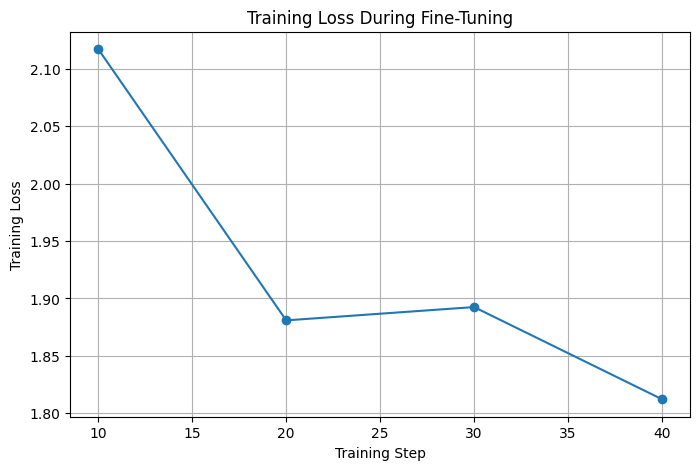

In [ ]:
import matplotlib.pyplot as plt

train_logs = log_df.dropna(subset=["loss"])

plt.figure(figsize=(8, 5))
plt.plot(train_logs["step"], train_logs["loss"], marker="o")
plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("Training Loss During Fine-Tuning")
plt.grid(True)
plt.show()

In [ ]:
#save the model
trainer.save_model("./ai-governance-qwen-lora")
tokenizer.save_pretrained("./ai-governance-qwen-lora")

('./ai-governance-qwen-lora/tokenizer_config.json',
 './ai-governance-qwen-lora/chat_template.jinja',
 './ai-governance-qwen-lora/tokenizer.json')

In [ ]:
import os

for file_name in os.listdir("./ai-governance-qwen-lora"):
    print(file_name)

adapter_model.safetensors
chat_template.jinja
tokenizer_config.json
adapter_config.json
tokenizer.json
README.md
training_args.bin


# Model Evaluation

In [ ]:
model.config.use_cache = True
model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [ ]:
def generate_answer(question, max_new_tokens=200):
    messages = [
        {
            "role": "system",
            "content": (
                "You are an AI Governance learning assistant. "
                "Provide clear, accurate, and responsible answers."
            ),
        },
        {
            "role": "user",
            "content": question,
        },
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    answer = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    )

    return answer.strip()

In [ ]:
#quick test
test_questions = [
    "What is AI governance?",
    "Why is data quality important in AI systems?",
    "What is algorithmic bias?",
    "What is the purpose of a model card?",
    "How can organizations reduce risks from large language models?",
]

for question in test_questions:
    print("=" * 80)
    print("Question:", question)
    print("\nAnswer:")
    print(generate_answer(question))
    print()

Question: What is AI governance?

Answer:
AI governance refers to the set of rules, policies, and procedures that govern the development, deployment, use, and oversight of artificial intelligence systems. It includes ensuring accountability for decisions made by AI systems, protecting privacy and data security, preventing bias and discrimination, and promoting transparency in decision-making processes. AI governance also involves establishing ethical standards and guidelines for developers and users of AI technologies.

Question: Why is data quality important in AI systems?

Answer:
Data quality is critical to the success of any machine learning model because it affects how well the model can learn from the training data. If the data is not clean or complete, then the model may be biased towards certain outcomes or may not generalize well to new data. Additionally, if the data is noisy or contains errors, then the model may produce inaccurate predictions or recommendations. Therefore, 

نقيم حسب الاتي:

1. Relevance
هل أجاب عن السؤال مباشرة؟

2. Accuracy
هل المعلومات صحيحة؟

3. Clarity
هل الإجابة مفهومة ومنظمة؟

4. Governance alignment
هل تستخدم مفاهيم الحوكمة بشكل صحيح؟

5. Hallucination
هل اخترع معايير أو قوانين أو حقائق؟

# Inference Pipeline

هنا راح احدد سلوك اجابة المودل وهنا اقدر احوكمه وافلتره

start build the inference pipline:
                    User
                      │
                      ▼
              Prompt Builder
                      │
                      ▼
                Tokenization
                      │
                      ▼
             Generation Engine
                      │
                      ▼
                Post Processing
                      │
                      ▼
                 Final Answer

In [ ]:
def build_messages(question):
    return [
        {
            "role": "system",
            "content": (
                "You are an AI Governance learning assistant. "
                "Provide accurate, concise, and responsible answers."
            ),
        },
        {
            "role": "user",
            "content": question,
        },
    ]

In [ ]:
#نسوي للسؤال المستخدم توكنايز
def build_prompt(messages):
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

def tokenize_prompt(prompt):
    return tokenizer(
        prompt,
        return_tensors="pt",
    ).to(model.device)

In [ ]:
#بدء توليد التوكنز generate engen
def generate_tokens(
    inputs,
    max_new_tokens=200,
    temperature=0.2,
):
    with torch.no_grad():

        return model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
#فك التوكنز من ارقام الى كلمات
def decode_answer(inputs, outputs):

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    return tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

In [ ]:
# ربط كل شيء
def ask(question):

    messages = build_messages(question)

    prompt = build_prompt(messages)

    inputs = tokenize_prompt(prompt)

    outputs = generate_tokens(inputs)

    answer = decode_answer(inputs, outputs)

    return answer

In [ ]:
#هنا يبدأ المستخدم بطرح الاسئلة
answer = ask("What is AI Governance?")
print(answer)

AI governance refers to the set of rules, policies, and procedures that govern how artificial intelligence (AI) systems should be designed, developed, deployed, and used in society. It includes considerations such as data privacy, bias, transparency, accountability, security, and ethical implications. The goal of AI governance is to ensure that AI technologies are safe, reliable, fair, and beneficial for all stakeholders.


# Deep Evaluation

In [ ]:
!pip install -q deepeval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 414.8/414.8 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.23.0 requires click<9.0.0,>=8.4.2, but you have click 8.3.3 which is incompatible.


In [ ]:
import deepeval
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric
from deepeval.evaluate import evaluate

In [ ]:
def extract_message(messages, role):
    """
    Extract the text content of the first message that matches the given role.

    Args:
        messages: A list of conversation messages.
        role: The role to search for, such as "user" or "assistant".

    Returns:
        The message content as a string.

    Raises:
        ValueError: If no message with the requested role is found.
    """

    for message in messages:
        if message["role"] == role:
            return message["content"]

    raise ValueError(f"No message with role '{role}' was found.")

In [ ]:
from deepeval.test_case import LLMTestCase


def create_test_cases(test_dataset, max_samples=None):
    """
    Generate model answers and convert test examples into DeepEval test cases.

    Args:
        test_dataset: The formatted SFT test dataset.
        max_samples: Maximum number of examples to evaluate.
                     If None, all examples are used.

    Returns:
        A list of LLMTestCase objects.
    """

    test_cases = []

    if max_samples is None:
        selected_dataset = test_dataset
    else:
        selected_dataset = test_dataset.select(
            range(min(max_samples, len(test_dataset)))
        )

    for index, sample in enumerate(selected_dataset):

        question = extract_message(
            sample["prompt"],
            role="user",
        )

        expected_answer = extract_message(
            sample["completion"],
            role="assistant",
        )

        actual_answer = ask(question)

        test_case = LLMTestCase(
            input=question,
            actual_output=actual_answer,
            expected_output=expected_answer,
        )

        test_cases.append(test_case)

        print(
            f"Created test case {index + 1}/{len(selected_dataset)}"
        )

    return test_cases

In [ ]:
test_cases = create_test_cases(test_sft)

#اختبار صغير للدوال
print("Input:")
print(test_cases[0].input)

print("\nActual output:")
print(test_cases[0].actual_output)

print("\nExpected output:")
print(test_cases[0].expected_output)

Created test case 1/21
Created test case 2/21
Created test case 3/21
Created test case 4/21
Created test case 5/21
Created test case 6/21
Created test case 7/21
Created test case 8/21
Created test case 9/21
Created test case 10/21
Created test case 11/21
Created test case 12/21
Created test case 13/21
Created test case 14/21
Created test case 15/21
Created test case 16/21
Created test case 17/21
Created test case 18/21
Created test case 19/21
Created test case 20/21
Created test case 21/21
Input:
Recommend a suitable response to the following model issue.

Additional information:
A customer-support LLM has high training performance, but its validation loss increases after the third epoch.

Actual output:
The problem is that the model's training data is not representative of the real-world scenario it will be used in. The solution is to collect more diverse data from different sources.

Expected output:
The pattern suggests overfitting. The team should consider restoring the checkpoint 

In [ ]:
import os
from getpass import getpass
from deepeval.models import OpenRouterModel
if (
    "OPENROUTER_API_KEY" not in os.environ
    or not os.environ["OPENROUTER_API_KEY"].startswith("sk-or-")
):
    os.environ["OPENROUTER_API_KEY"] = getpass(
        "Enter your OpenRouter API key: "
    )

In [ ]:
judge_model = OpenRouterModel(
    model="google/gemini-3.5-flash",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
)

In [ ]:
answer_relevancy_metric = AnswerRelevancyMetric(
    threshold=0.7, #درجة النجاح
    model=judge_model,
    include_reason=True,
    strict_mode=False,
    async_mode=True,
    verbose_mode=False,
)

In [ ]:
#اختبار بسيط
answer_relevancy_metric.measure(test_cases[0])

print("Answer relevancy score:")
print(answer_relevancy_metric.score)

print("\nEvaluation reason:")
print(answer_relevancy_metric.reason)

print("\nPassed:")
print(answer_relevancy_metric.is_successful())

Output()

Answer relevancy score:
0.5

Evaluation reason:
The score is 0.50 because while the response attempts to address the model issue, it introduces irrelevant analysis by attributing the increasing validation loss to unrepresentative training data rather than identifying it as a classic case of overfitting.

Passed:
False


In [ ]:
evaluation_results = evaluate(
    test_cases=test_cases,
    metrics=[answer_relevancy_metric],
)

✨ You're running DeepEval's latest Answer Relevancy Metric! (using google/gemini-3.5-flash (OpenRouter), 
strict=False, async_mode=True)...

Output()

INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a_execute_llm_test_cases
INFO:deepeval.evaluate.execute.e2e:in _a

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🚀 DeepEval Evaluation Results                                                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_0                                                                                                 │
│  ├──   Input:              Recommend a suitable response to the following model issue.                          │
│  │                                                                                                              │
│  │                         Additional information:                                                              │
│  │                         A customer-support LLM has high training performance, but its validation loss        │
│  │                         increases after the third epoch.                                                     │
│  │     Actual Output:      The problem is that the model's training data is not representative of the           │
│  │                         real-world scenario it will be used in. The solution is to collect more diverse      │
│  │                         data from different sources.                                                         │
│  │     Expected Output:    The pattern suggests overfitting. The team should consider restoring the             │
│  │                         checkpoint from the best validation epoch, reducing the number of epochs,            │
│  │                         applying early stopping, reviewing the dataset size and diversity, or increasing     │
│  │                         regularization such as dropout or weight decay.                                      │
│  └── Metrics                                                                                                    │
│       Status ┃ Metric           ┃ Score ┃ Threshold ┃ Reason                                                    │
│      ━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  │
│        FAIL  │ Answer Relevancy │ 0.50  │ 0.70      │ The score is 0.50 because while the response attempts     │
│              │                  │       │           │ to address the model's performance issue, it introduces   │
│              │                  │       │           │ irrelevant arguments about the training data being        │
│              │                  │       │           │ unrepresentative of the real world, which distracts       │
│              │                  │       │           │ from the actual training process issue of overfitting     │
│              │                  │       │           │ indicated by the rising validation loss.                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯
╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  ❌ test_case_1                                                                                                 │
│  ├──   Input:              Give me a list of things to enable a support team on their technical strengths       │
│  │     Actual Output:      - Technical knowledge                                                                │
│  │                         - Problem solving skills      

⚠ WARNING: No hyperparameters logged.
» ]8;id=26225;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Evaluation completed 🎉! (time taken: 24.28s | token cost: 0.402006 USD)
» Test Results (21 total tests):
   » Pass Rate: 76.19% | Passed: 16 | Failed: 5

 ================================================================================ 

» Want to share evals with your team, or a place for your test cases to live? ❤️ 🏡
  » Run 'deepeval view' to analyze and save testing results on Confident AI.

### Evaluation Summary

The fine-tuned model achieved an average Answer Relevancy score of **0.82**
across **21 test cases**.

- Passed: 16
- Failed: 5
- Pass rate: 76.19%
- Evaluation threshold: 0.70

The results indicate that the model generally produces answers relevant to the
user's questions. However, several failed cases show that the model may provide
partially relevant but conceptually inaccurate explanations. Therefore, answer
relevancy alone is not sufficient to establish factual correctness.